## Clustering Exercise: Customer Segmentation in E-commerce

### Overview
<a href="https://archive.ics.uci.edu/ml/datasets/online+retail">Online retail is a transnational data set</a> which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

| Column Name     | Description                                                         |
| --------------- | ------------------------------------------------------------------- |
| **InvoiceNo**   | Unique identifier for each transaction (a 6-digit integral number). |
| **StockCode**   | Product (item) code.                                                |
| **Description** | Product (item) name.                                                |
| **Quantity**    | The number of units of the product purchased per transaction.       |
| **InvoiceDate** | Date and time when the transaction occurred.                        |
| **UnitPrice**   | Price per unit of the product (in GBP).                             |
| **CustomerID**  | Unique identifier for each customer.                                |
| **Country**     | The name of the country where the customer resides.                 |


### Goal
We aim to develop suitable and efficient marketing strategy for each segement of the Customers. Therefore, clustering is required to find meaningful customers segments

### Approach
Apply K-means clustering to to segment customers based on existing behavior to predict how a new customer is likely to act in the future.  That should ensure the company can target its customers efficiently with a corresponding marketing strategy.

We will adopt the RFM analysis by calculating the three RFM metrics:
- R (Recency): Number of days since last purchase
- F (Frequency): Number of tracsactions
- M (Monetary): Total amount of transactions (revenue contributed).

We will use the RFM new variables as input for the clustering

Follow the Jupyter notebook below and answer the tasks marked as ✅ Task for Students.

<a id="1"></a> <br>
### 1. Import the basic packages and set the random seed

In [140]:
# import required libraries for dataframe and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
# import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [142]:
# to ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 2. Load and Preview the Data

Start by loading the dataset and inspecting the first few rows.

In [143]:
# Load the dataset
data=pd.read_csv('./OnlineRetail.csv', encoding= 'cp1252' , header=0)

# Preview the dataset
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [144]:
# check column types and existance of NaNs
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [145]:
# check the distribution of the numerical features
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


<a id="2"></a> <br>
### 3. Data Cleansing

✅ Task for Students: Drop rows with missing values.

In [146]:
# Drop all rows with missing values: this will drop all rows where customer ID is missing, notice that this cannot be imputed
# your code here
data=data.dropna()
data.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

✅ Task for Students: Remove any entries where `Quantity` or `UnitPrice` is zero or negative, as these entries likely represent errors.

In [147]:
# Remove rows with Quantity and UnitPrice <= 0
# your code here
data = data[data["Quantity"]>0]
data= data[data["UnitPrice"]>0]

In [148]:
# Confirm cleaned data
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


<a id="3"></a> <br>
### 4. Feature Engineering

✅ Task for Students:
For customer segmentation, it is often need to conduct an RFM analysis by calculating three customers metrics:
- R (Recency): Number of days since last purchase
- F (Frequency): Number of tracsactions
- M (Monetary): Total amount of transactions (revenue contributed).

Your task is to compute these three features for each customer.

In [149]:
# your code here
recency=[]
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])
snapshot_date=data["InvoiceDate"].max() + pd.Timedelta(days=1)
for cust_id in data["CustomerID"].unique():
    last_purchase=data[data["CustomerID"] == cust_id]["InvoiceDate"].max()
    recency.append((snapshot_date-last_purchase).days)

number_transactions=[]
for cust_id in data["CustomerID"].unique():
    number_transactions.append(data[data["CustomerID"]==cust_id]["InvoiceNo"].nunique())
    
total_sum=[]
data["TotalPaid"]=data["Quantity"]*data["UnitPrice"]
for cust_id in data["CustomerID"].unique():
    total_sum.append(data[data["CustomerID"]==cust_id]["TotalPaid"].sum())
    
rfm=pd.DataFrame({"Recency": recency,
          "Frequency": number_transactions,
          "Monetary": total_sum},
         index=data["CustomerID"].unique())

In [150]:
# Preview the RFM data
rfm.head()

,Recency,Frequency,Monetary
17850.0,372,34,5391.21
13047.0,32,10,3237.54
12583.0,3,15,7281.38
13748.0,96,5,948.25
15100.0,334,3,876.00


### 5. Data Exploration and Visualization

Use visualizations to understand the distributions of **Recency**, **Frequency**, and **Monetary** values.

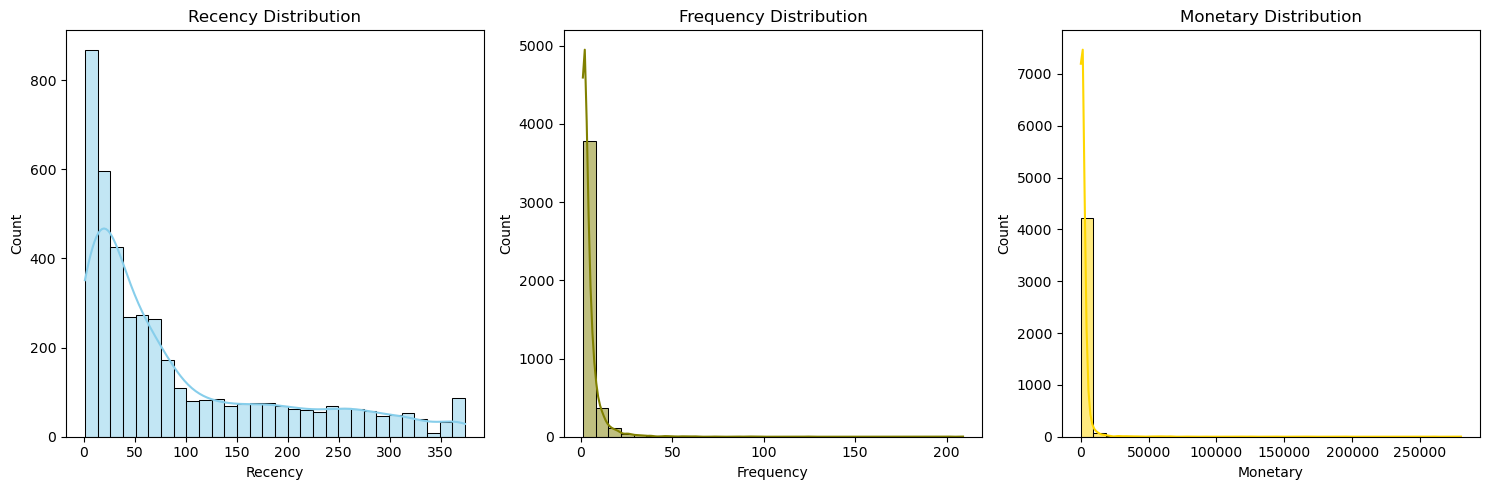

In [151]:
# Plot histograms for each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1], color="olive")
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color="gold")
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

✅ Task for Students: use box plot to plot the distribution of each the new features 

Text(0, 0.5, 'Count')

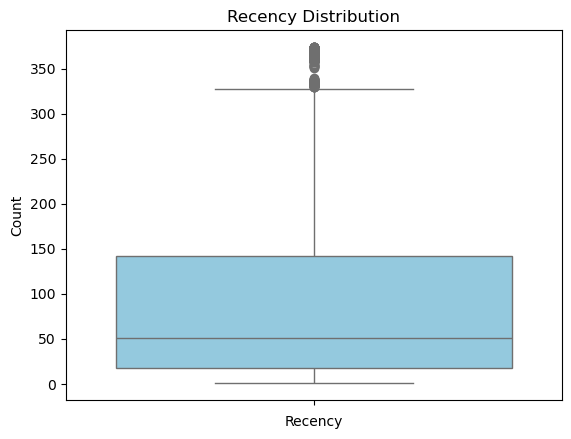

In [152]:
# Outlier Analysis of Amount, Frequency, and Recency
# your code here
sns.boxplot(rfm["Recency"], color="skyblue")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

Notice: An outlier: is an observation that lies an abnormal distance from other values in a random sample from a population. In a sense, this definition leaves it up to the analyst (or a consensus process) to decide what will be considered abnormal.

✅ Task for students: Use the Interquartile Range (IQR) method to replace outliers. 

**The Interquartile Range (IQR) method** is a statistical approach to identify outliers in a dataset. It calculates the difference between the 75th percentile (Q3) and the 25th percentile (Q1) of the data. Data points outside the "fence" defined by Q1 - 1.5xIQR and Q3 + 1.5xIQR are considered outliers.

In [153]:
# your code here
Q1 = rfm["Recency"].quantile(0.25)
Q3 = rfm["Recency"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm["Recency"] = rfm["Recency"].clip(lower=lower_bound, upper=upper_bound)

Q1 = rfm["Monetary"].quantile(0.25)
Q3 = rfm["Monetary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
rfm["Monetary"] = rfm["Monetary"].clip(lower=lower_bound, upper=upper_bound)

Q1 = rfm["Frequency"].quantile(0.25)
Q3 = rfm["Frequency"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
rfm["Frequency"] = rfm["Frequency"].clip(lower=lower_bound, upper=upper_bound)

### 5. Scaling Data for Clustering

✅ Task for students: use the standard scaler from Sklearn to scale the features

In [154]:
# your code here
scaler=StandardScaler()

rfm_scaled= pd.DataFrame(scaler.fit_transform(rfm),columns=rfm.columns,index=rfm.index)


In [155]:
rfm_scaled.head()

,Recency,Frequency,Monetary
17850.0,2.433960,2.471699,2.204224
13047.0,-0.611673,2.142725,1.807262
12583.0,-0.910062,2.471699,2.204224
13748.0,0.046843,0.497858,-0.186998
15100.0,2.433960,-0.160088,-0.249937


### 6. Determining the Optimal Number of Clusters (Elbow Method)

✅ Task for students: Use the Elbow Method to find the optimal number of clusters.

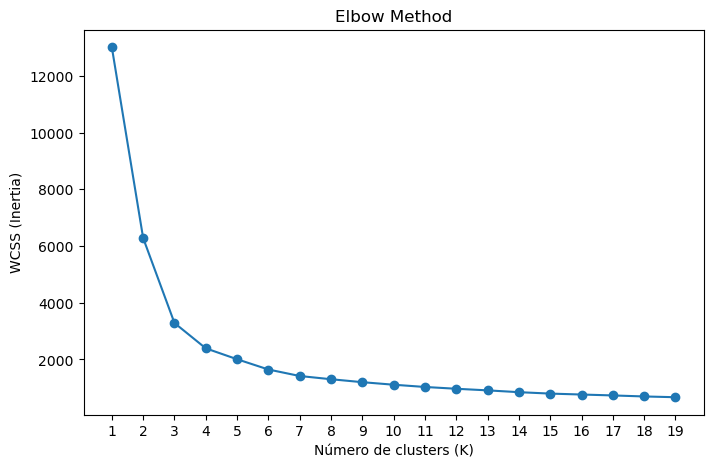

In [156]:
# Elbow Method to find the optimal number of clusters

# your code here
wcss=[]
k_range= range(1,20)
for k in k_range:
    k_means=KMeans(n_clusters=k, random_state=42, n_init=10)
    k_means.fit(rfm_scaled)
    wcss.append(k_means.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Número de clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()

### 7. Apply K-means Clustering

✅ Task for students: Using the chosen optimal `k` (e.g., 4), perform K-means clustering.

In [157]:
# Apply K-means with optimal number of clusters
optimal_k = 4

# your code here
k_means=KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"]=k_means.fit_predict(rfm)

In [158]:
# Preview clustered data
rfm.head(30)

,Recency,Frequency,Monetary,Cluster
17850.0,328,11,3693.2275,3
13047.0,32,10,3237.5400,3
12583.0,3,11,3693.2275,3
13748.0,96,5,948.2500,2
15100.0,328,3,876.0000,2
15291.0,26,11,3693.2275,3
14688.0,8,11,3693.2275,3
17809.0,16,11,3693.2275,3
15311.0,1,11,3693.2275,3
16098.0,88,7,2005.6300,1


### 8. Cluster Insights and Interpretation
✅ Task for students: Interpret each cluster based on average **Recency**, **Frequency**, and **Monetary** average (mean) values across the clusters.
- find the mean value for each of the three variables for each cluster
- normalize this value by dividing it by maximum mean value across the different clusters: mean recency cluster 1/maximum mean of recency across all clusters

In [164]:
# Calculate average values per cluster

# your code here
rfm.groupby("Cluster")[["Recency", "Monetary", "Frequency"]].mean()

,Recency,Monetary,Frequency
Cluster,,,
0,130.771532,327.845060,1.585222
1,45.833948,2122.291015,5.754613
2,66.180542,1058.573873,3.440321
3,29.330523,3567.972940,8.564924


In [160]:
# normalize per feature. Otherwise, it is impossible to compare the clusters
# your code here



### 10. Conclusion and Recommendations

✅ Task for students: Discuss insights such as which customer segments are "high-value" or "at risk" of churning, and potential strategies to engage each segment.

In [161]:
answer =
    '''
     your answer here
    '''

SyntaxError: invalid syntax (4270506997.py, line 1)